# Diabetes Challenge

Your task today is to **analyze** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has Diabetes or not.

## Task:
- Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why? 
- Use at least two different classification algorithms we have learned so far to predict Diabetes patients. 
- Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.
- Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.
- **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.

Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.


## Helpful links and advise:
- [sklearn documentation on hyperparameter tuning](https://scikit-learn.org/stable/modules/grid_search.html#grid-search)
- It might be helpful to check some sources on how to deal with imbalanced data. 
    * [8 Tactics to Combat Imbalanced Classes](https://machinelearningmastery.com/tactics-to-combat-imbalanced-classes-in-your-machine-learning-dataset/)
    * [Random-Oversampling/Undersampling](https://machinelearningmastery.com/random-oversampling-and-undersampling-for-imbalanced-classification/)


# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

In [739]:
# Import of relevant packages
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, recall_score, precision_score

from sklearn.linear_model import LogisticRegression

# Set random seed 
RSEED = 42
warnings.filterwarnings("ignore")

# Define a plotting style to be used for all plots in this notebook
plt.style.use('tableau-colorblind10')
RSEED = 10
from timeit import default_timer as timer

In [740]:
# Read database string from .env file (no need to change anything)
load_dotenv()

DB_STRING = os.getenv('DB_STRING')

db = create_engine(DB_STRING)

In [741]:
# Define query to download data (add your query here)
#correct query
query_string = "set schema 'diabetes'; SELECT * FROM patient p LEFT JOIN blood_metrics bd ON p.id = bd.patientid LEFT JOIN skin s ON p.id = s.patientid LEFT JOIN pedigree_outcome po ON p.id = po.PatientId where bd.measurement_date = '2022-12-13';"
#test queries 
#query_string = "set schema 'diabetes'; SELECT * FROM patient p LEFT JOIN blood_metrics bd ON p.id = bd.patientid LEFT JOIN skin s ON p.id = s.patientid LEFT JOIN pedigree_outcome po ON p.id = po.PatientId;"
#query_string = "set schema 'diabetes';  SELECT * FROM patient p Left JOIN skin s ON p.id = s.patientid  Left JOIN blood_metrics bm ON p.id = bm.patientid Left JOIN  pedigree_outcome pd_outcm ON p.id = pd_outcm.patientid where bm.measurement_date = '2022-12-13';"
#Import with pandas
df_sqlalchemy = pd.read_sql(query_string, db)
df_sqlalchemy.head()

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,patientid,measurement_date,skinthickness,diabetespedigreefunction,outcome
0,1,50,6,33.6,0,148,72,1,2022-12-13,35,1,1
1,2,31,1,26.6,0,85,66,2,2022-12-13,29,0,0
2,3,32,8,23.3,0,183,64,3,2022-12-13,0,1,1
3,4,21,1,28.1,94,89,66,4,2022-12-13,23,0,0
4,5,33,0,43.1,168,137,40,5,2022-12-13,35,2,1


In [742]:
# Save dataframe as .csv file
df_sqlalchemy.to_csv("data/diabetes_data.csv", index=False)

In [743]:
#saving data in a csv file in csv
df= pd.read_csv('data/diabetes_data.csv')
# the data frame we are going to use
df_db = df.copy()
df_db.head()

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,patientid,measurement_date,skinthickness,diabetespedigreefunction,outcome
0,1,50,6,33.6,0,148,72,1,2022-12-13,35,1,1
1,2,31,1,26.6,0,85,66,2,2022-12-13,29,0,0
2,3,32,8,23.3,0,183,64,3,2022-12-13,0,1,1
3,4,21,1,28.1,94,89,66,4,2022-12-13,23,0,0
4,5,33,0,43.1,168,137,40,5,2022-12-13,35,2,1


In [744]:
df_db.shape

(768, 12)

In [745]:
df_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        768 non-null    int64  
 1   Age                       768 non-null    int64  
 2   pregnancies               768 non-null    int64  
 3   bmi                       768 non-null    float64
 4   insulin                   768 non-null    int64  
 5   glucose                   768 non-null    int64  
 6   bloodpressure             768 non-null    int64  
 7   patientid                 768 non-null    int64  
 8   measurement_date          768 non-null    object 
 9   skinthickness             768 non-null    int64  
 10  diabetespedigreefunction  768 non-null    int64  
 11  outcome                   768 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 72.1+ KB


In [746]:
df_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        768 non-null    int64  
 1   Age                       768 non-null    int64  
 2   pregnancies               768 non-null    int64  
 3   bmi                       768 non-null    float64
 4   insulin                   768 non-null    int64  
 5   glucose                   768 non-null    int64  
 6   bloodpressure             768 non-null    int64  
 7   patientid                 768 non-null    int64  
 8   measurement_date          768 non-null    object 
 9   skinthickness             768 non-null    int64  
 10  diabetespedigreefunction  768 non-null    int64  
 11  outcome                   768 non-null    int64  
dtypes: float64(1), int64(10), object(1)
memory usage: 72.1+ KB


In [747]:
df_db.describe()

,id,Age,pregnancies,bmi,insulin,glucose,bloodpressure,patientid,skinthickness,diabetespedigreefunction,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,384.500000,33.240885,3.845052,31.992578,79.799479,120.894531,69.105469,384.500000,20.536458,0.373698,0.348958
std,221.846794,11.760232,3.369578,7.884160,115.244002,31.972618,19.355807,221.846794,15.952218,0.510322,0.476951
min,1.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,192.750000,24.000000,1.000000,27.300000,0.000000,99.000000,62.000000,192.750000,0.000000,0.000000,0.000000
50%,384.500000,29.000000,3.000000,32.000000,30.500000,117.000000,72.000000,384.500000,23.000000,0.000000,0.000000
75%,576.250000,41.000000,6.000000,36.600000,127.250000,140.250000,80.000000,576.250000,32.000000,1.000000,1.000000
max,768.000000,81.000000,17.000000,67.100000,846.000000,199.000000,122.000000,768.000000,99.000000,2.000000,1.000000


In [748]:
#checking missing data
df_db.isnull().sum()

id                          0
Age                         0
pregnancies                 0
bmi                         0
insulin                     0
glucose                     0
bloodpressure               0
patientid                   0
measurement_date            0
skinthickness               0
diabetespedigreefunction    0
outcome                     0
dtype: int64

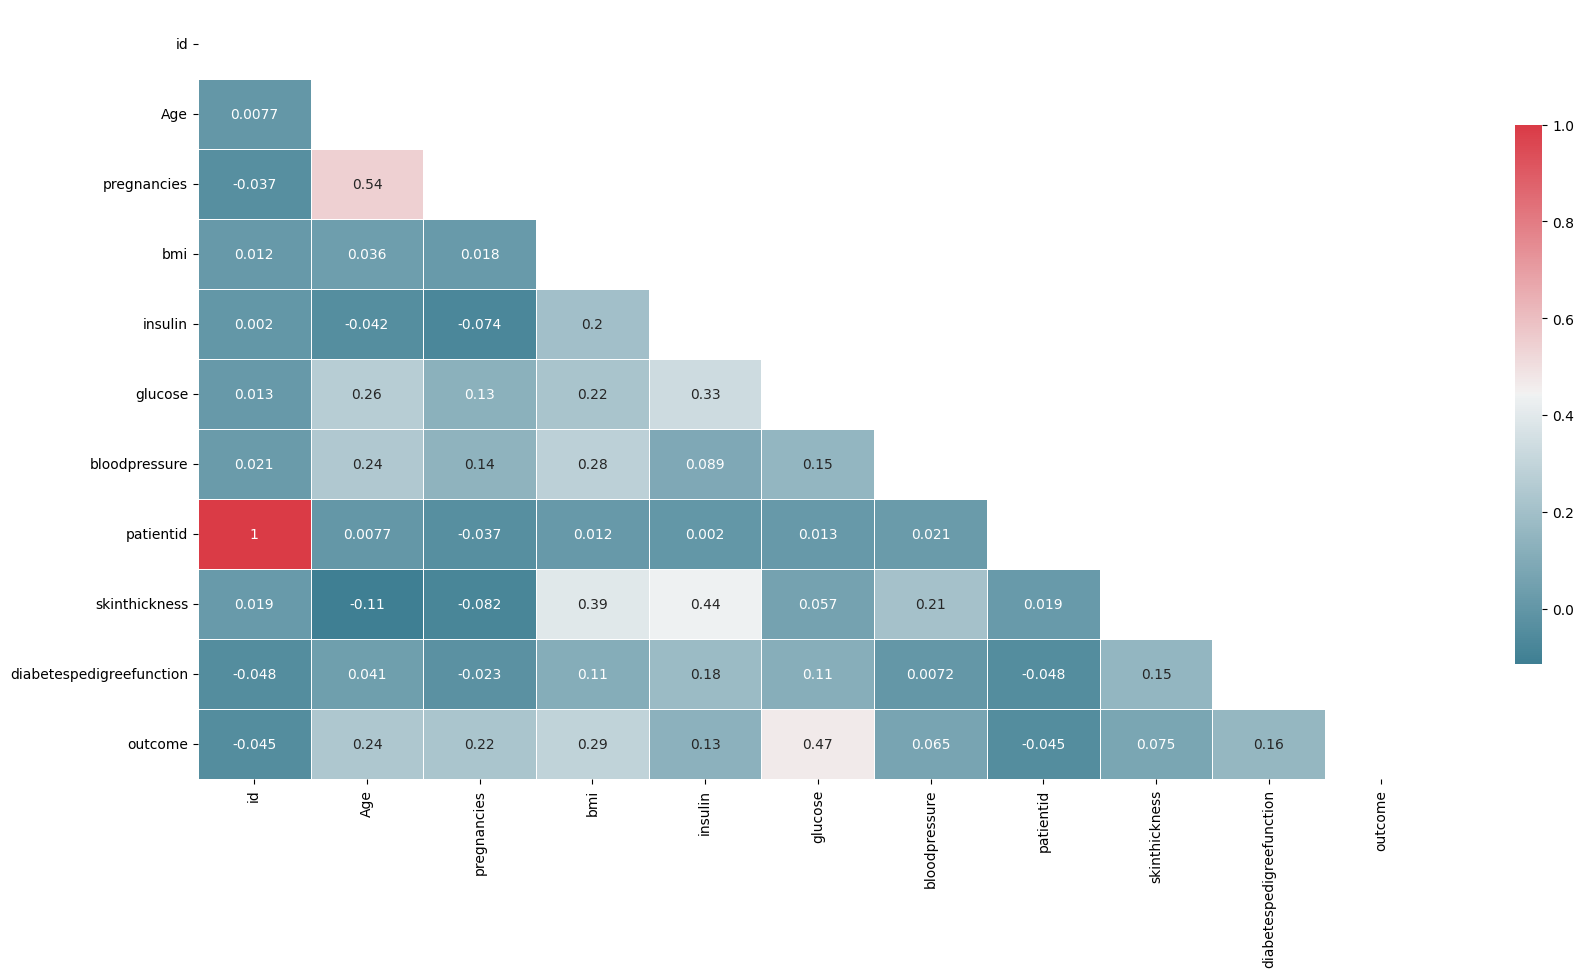

In [749]:
# Compute correlations
plt.figure(figsize = (20,10))
correlations = df_db.corr(numeric_only = True)
# Generate a mask for the upper triangle
mask = np.zeros_like(correlations)
mask[np.triu_indices_from(mask)] = True
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlations, mask=mask, cmap=cmap, vmax=1, annot=True,
            linewidths=.5, cbar_kws={"shrink": .7});

# From here we drops 'id', patientid and  measurment_date

In [750]:
# we drop the id column (NOT THE PATIENT_ID!...we are gonna need it)
df_dbdc = df_db.drop(['id', 'patientid', 'measurement_date'],axis=1)
df_dbdc.head()

,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
0,50,6,33.6,0,148,72,35,1,1
1,31,1,26.6,0,85,66,29,0,0
2,32,8,23.3,0,183,64,0,1,1
3,21,1,28.1,94,89,66,23,0,0
4,33,0,43.1,168,137,40,35,2,1


In [751]:
df_dbdc.head(100)

,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
0,50,6,33.6,0,148,72,35,1,1
1,31,1,26.6,0,85,66,29,0,0
2,32,8,23.3,0,183,64,0,1,1
3,21,1,28.1,94,89,66,23,0,0
4,33,0,43.1,168,137,40,35,2,1
...,...,...,...,...,...,...,...,...,...
95,40,6,33.9,228,144,72,27,0,0
96,24,2,31.6,0,92,62,28,0,0
97,22,1,20.4,76,71,48,18,0,0
98,23,6,28.7,64,93,50,30,0,0


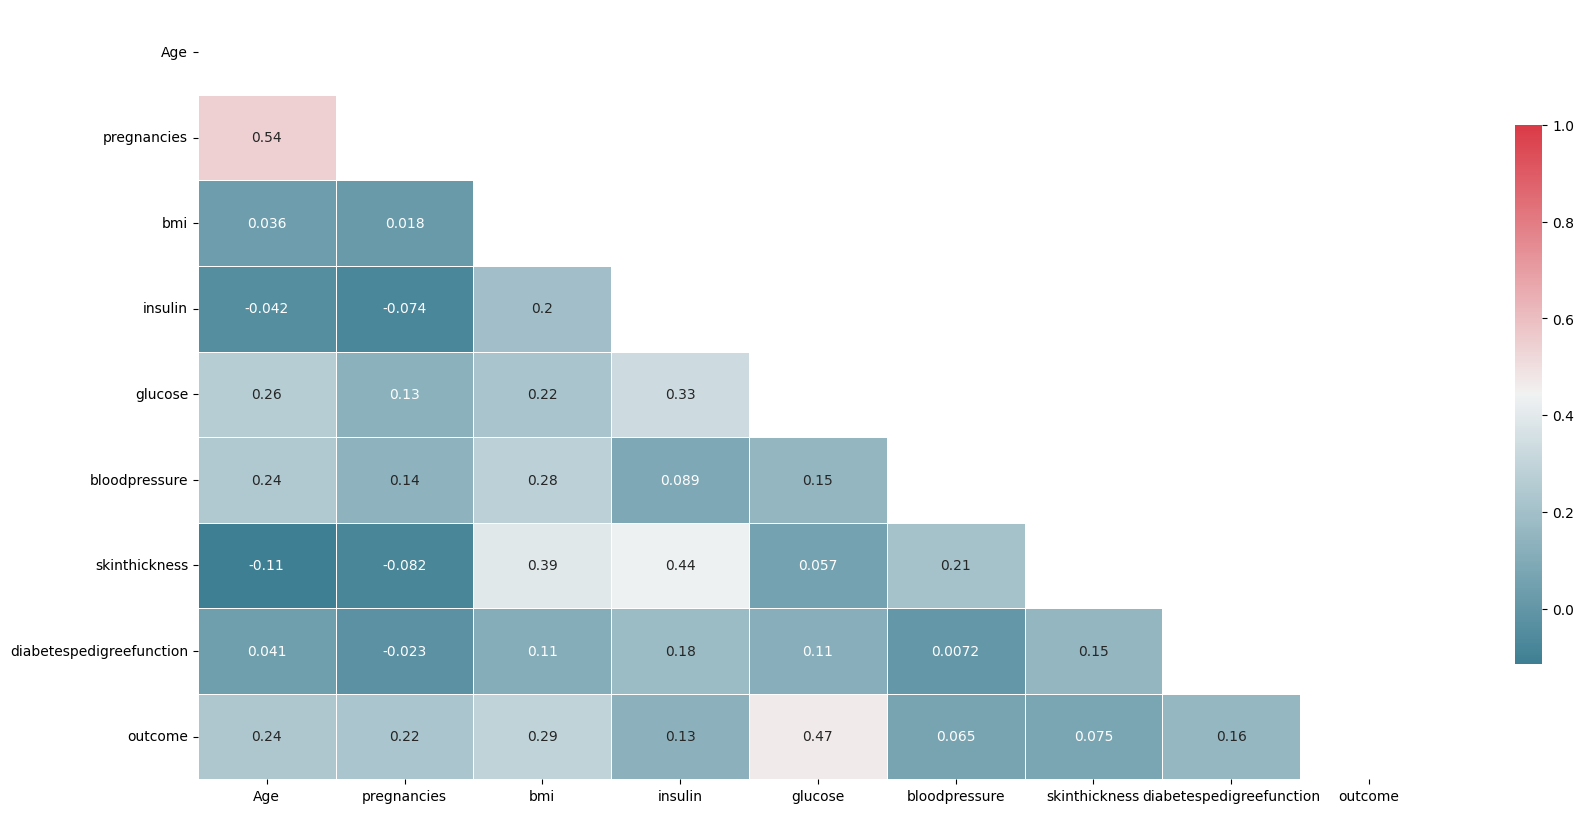

In [752]:
# Compute correlations
plt.figure(figsize = (20,10))
correlations = df_dbdc.corr(numeric_only = True)
# Generate a mask for the upper triangle
mask = np.zeros_like(correlations)
mask[np.triu_indices_from(mask)] = True
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlations, mask=mask, cmap=cmap, vmax=1, annot=True,
            linewidths=.5, cbar_kws={"shrink": .7});

In [753]:
# outcome is correlated with glucose, bmi, age, pregnancies, diabetesdigreefuntion, 

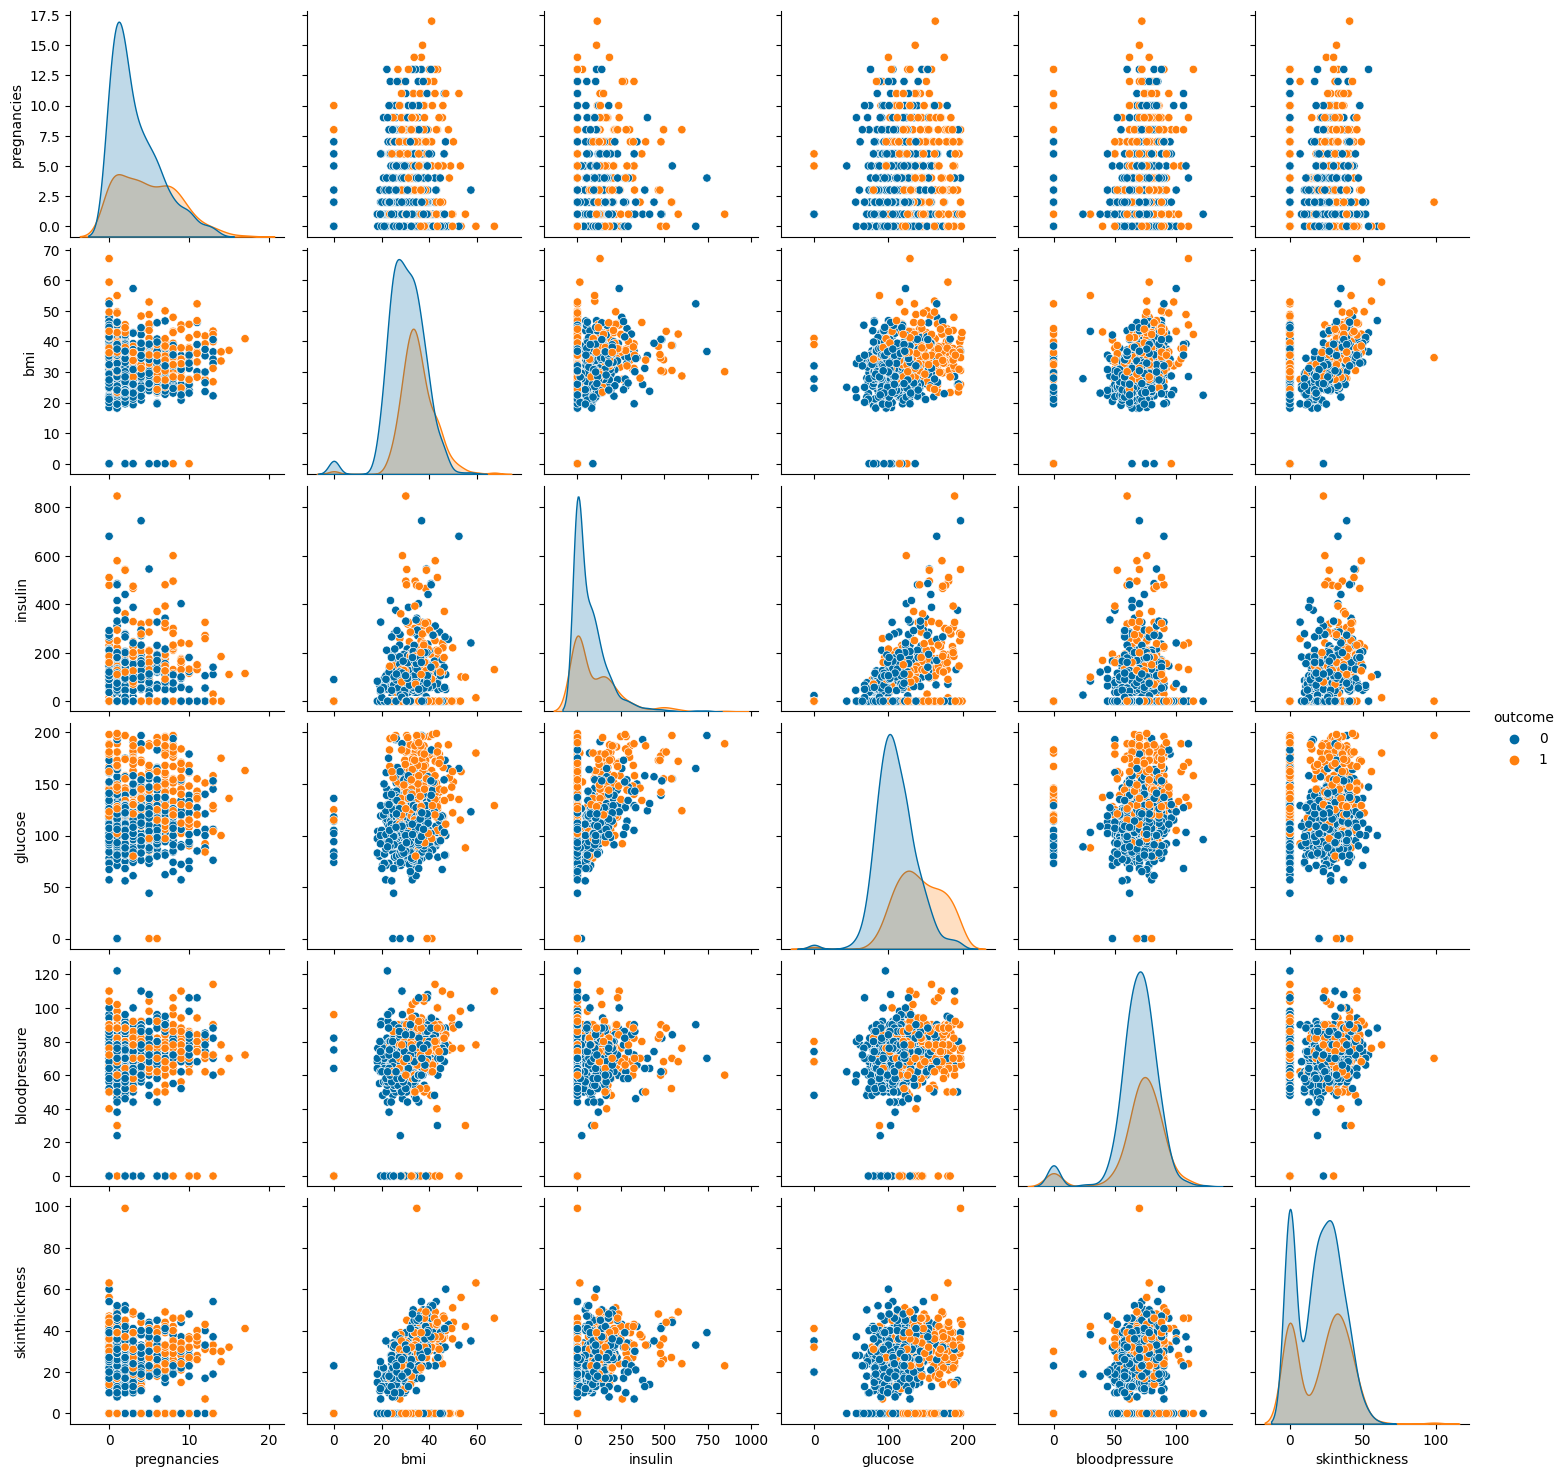

In [754]:

sns.pairplot(df_dbdc[['pregnancies', 'bmi', 'insulin', 'glucose', 'bloodpressure', 'skinthickness', 'outcome']], hue="outcome");
#sns.pairplot(df_dbdc, hue="outcome", height=3);

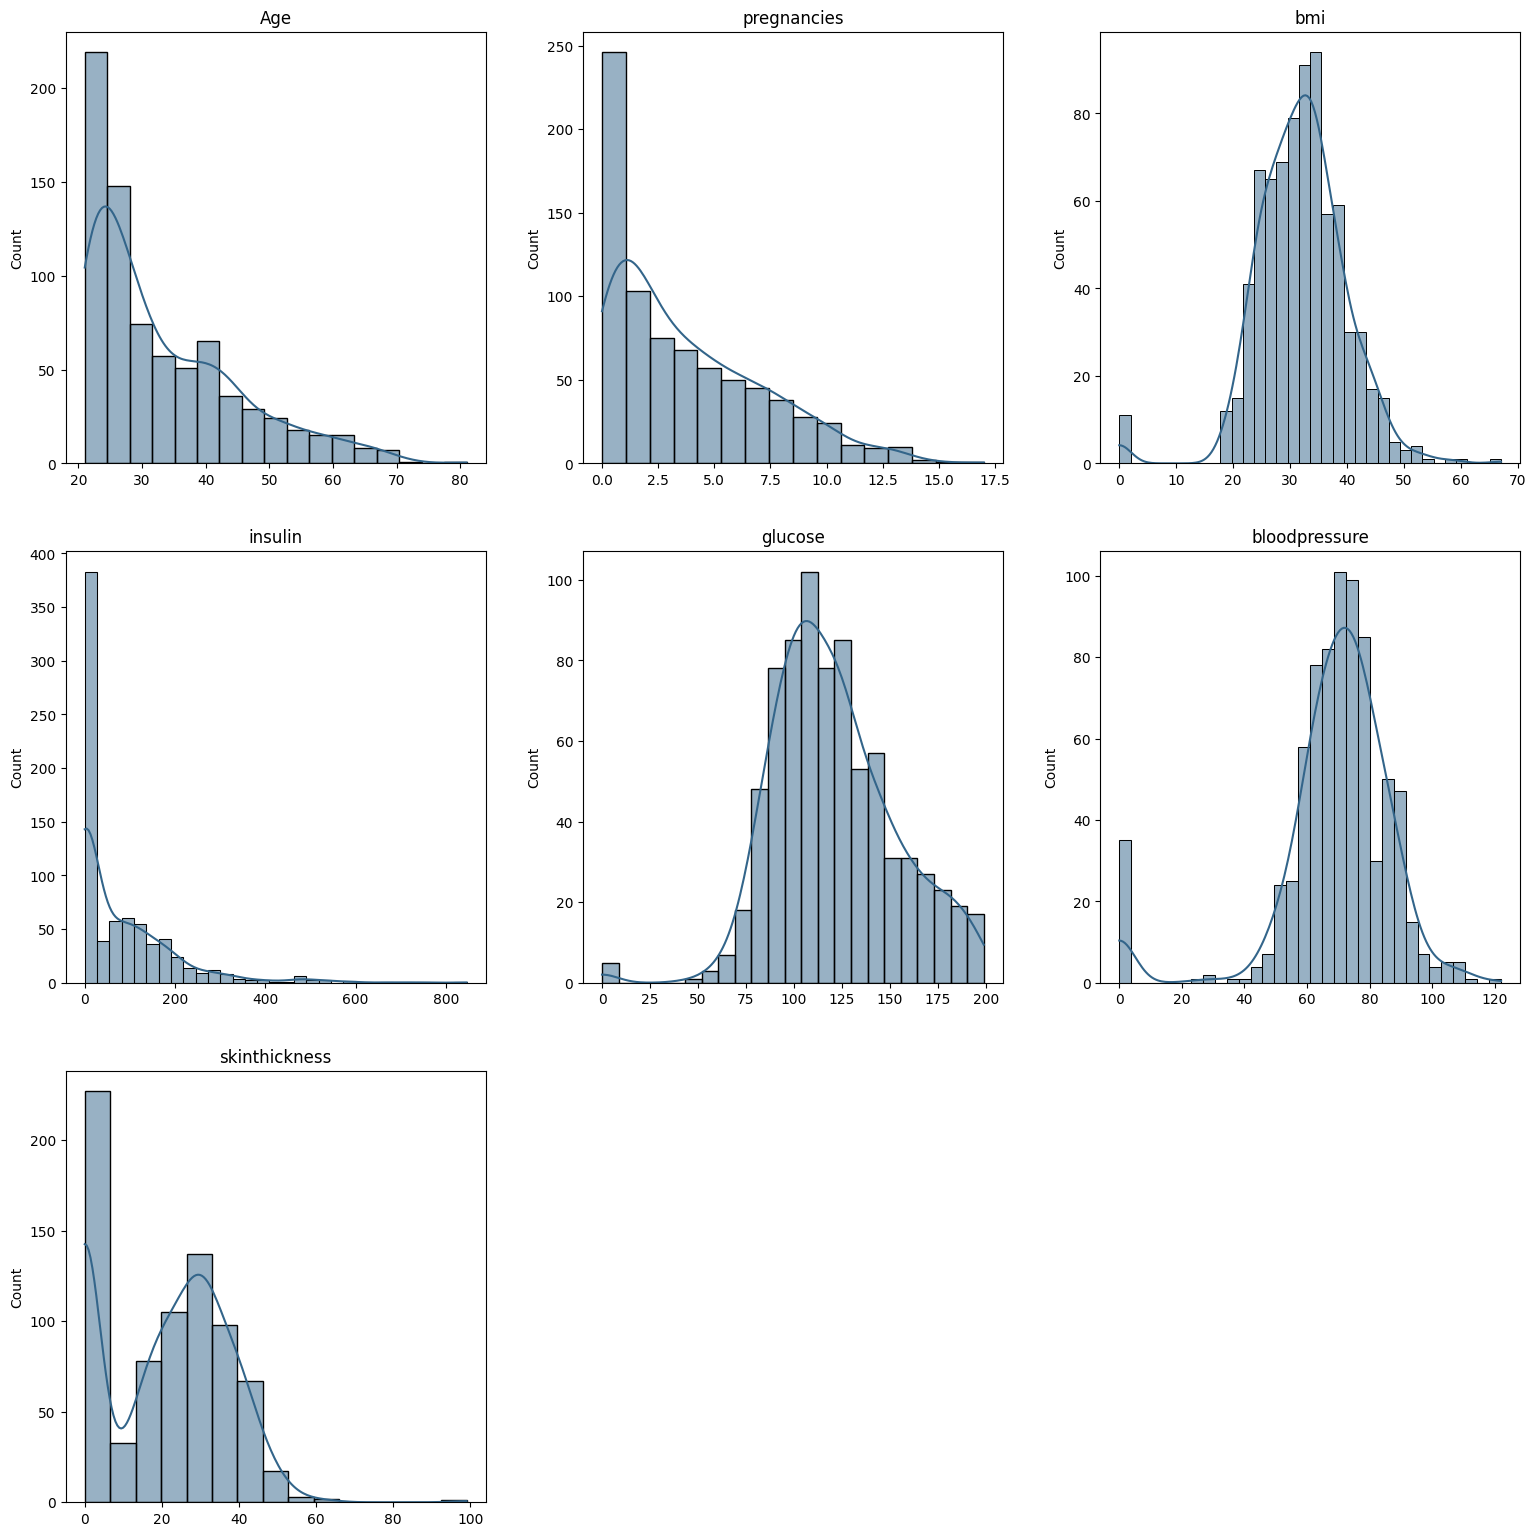

In [755]:
# Plot histograms for cleaned features
plot_column = ['Age', 'pregnancies', 'bmi', 'insulin', 'glucose', 'bloodpressure', 'skinthickness', 'diabetespedigreefunction']
fig,ax = plt.subplots(3,3,figsize=(16,16))
count = 0
#for item in df_dbdc.columns.tolist():
for item in plot_column:    
    sns.histplot(df_dbdc[item], kde=True,ax=ax[int(count/3)][count%3], color='#33658A').set(title=item, xlabel='')
    count += 1
ax.flat[-1].set_visible(False)
ax.flat[-2].set_visible(False)
fig.tight_layout(pad=3)

In [756]:
df_dbdc.columns

Index(['Age', 'pregnancies', 'bmi', 'insulin', 'glucose', 'bloodpressure',
       'skinthickness', 'diabetespedigreefunction', 'outcome'],
      dtype='object')

- Glucose, BloodPresure, SkinThickness ,insulin and BMI has many zeros
- pregnancies, age, insulin and diabetespedigreefunction are positively right skewed

In [757]:
# defining target and features data frames. From 353 rows we passed to 212
#y = df_dbdc['outcome'] 
#X = df_dbdc.drop('outcome', axis=1)
#X = df_dbdc[['Age', 'pregnancies', 'bmi', 'insulin', 'glucose', 'bloodpressure','measurement_date', 'skinthickness', 'diabetespedigreefunction']] 
#y.shape,X.shape

In [758]:
#X1 = X.replace(0,np.NaN)
features = df_dbdc.columns.tolist()
features.remove('outcome')
def zero_to_nan(df_dbdc, features):
    df_dbdc[features] =  df_dbdc[features].replace(0,np.NaN)
    return df_dbdc
#df_dbdc.head(100)
#col0 = ['pregnancies', 'bmi', 'insulin', 'glucose', 'bloodpressure', 'skinthickness']
col0 = ['bmi', 'insulin', 'glucose', 'bloodpressure', 'skinthickness']
for col in col0:
    df_dbdc = zero_to_nan(df_dbdc, col)
#df_dbdc_f.head(100)    
print(df_dbdc.query("bmi.isnull() & bloodpressure.isnull()").shape[0])
index_list = df_dbdc.query("bmi.isnull() & bloodpressure.isnull()").index.tolist()
df_dbdc.query("bmi.isnull() & bloodpressure.isnull()")
#print(df_dbdc.query("bmi.isnull() & insulin.isnull() & glucose.isnull() & bloodpressure.isnull() & skinthickness.isnull()").shape[0])
#index_list = df_dbdc.query("bmi.isnull() & insulin.isnull() & glucose.isnull() & bloodpressure.isnull() & skinthickness.isnull()").index.tolist()
#df_dbdc.query("bmi.isnull() & insulin.isnull() & glucose.isnull() & bloodpressure.isnull() & skinthickness.isnull()")
#df_dbdc_f.head(100)#
#print (index_list)


7


,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
49,24,7,NaN,NaN,105.0,NaN,NaN,0,0
60,21,2,NaN,NaN,84.0,NaN,NaN,0,0
81,22,2,NaN,NaN,74.0,NaN,NaN,0,0
426,25,0,NaN,NaN,94.0,NaN,NaN,0,0
494,22,3,NaN,NaN,80.0,NaN,NaN,0,0
522,26,6,NaN,NaN,114.0,NaN,NaN,0,0
706,30,10,NaN,NaN,115.0,NaN,NaN,0,1


In [759]:
df_dbdc.isnull().sum()

Age                           0
pregnancies                   0
bmi                          11
insulin                     374
glucose                       5
bloodpressure                35
skinthickness               227
diabetespedigreefunction      0
outcome                       0
dtype: int64

In [760]:
df_dbdc_dp = df_dbdc.drop(index_list)

In [761]:
df_dbdc_dp.isnull().sum()

Age                           0
pregnancies                   0
bmi                           4
insulin                     367
glucose                       5
bloodpressure                28
skinthickness               220
diabetespedigreefunction      0
outcome                       0
dtype: int64

In [762]:
df_dbdc_dp.head()

,Age,pregnancies,bmi,insulin,glucose,bloodpressure,skinthickness,diabetespedigreefunction,outcome
0,50,6,33.6,NaN,148.0,72.0,35.0,1,1
1,31,1,26.6,NaN,85.0,66.0,29.0,0,0
2,32,8,23.3,NaN,183.0,64.0,NaN,1,1
3,21,1,28.1,94.0,89.0,66.0,23.0,0,0
4,33,0,43.1,168.0,137.0,40.0,35.0,2,1


In [763]:
df_dbdc_dp.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,761.0,33.323259,11.779469,21.0,24.00,29.0,41.0,81.0
pregnancies,761.0,3.840999,3.370491,0.0,1.00,3.0,6.0,17.0
bmi,757.0,32.457464,6.924988,18.2,27.50,32.3,36.6,67.1
insulin,394.0,155.548223,118.775855,14.0,76.25,125.0,190.0,846.0
glucose,756.0,121.932540,30.533481,44.0,100.00,117.0,141.0,199.0
bloodpressure,733.0,72.405184,12.382158,24.0,64.00,72.0,80.0,122.0
skinthickness,541.0,29.153420,10.476982,7.0,22.00,29.0,36.0,99.0
diabetespedigreefunction,761.0,0.377135,0.511399,0.0,0.00,0.0,1.0,2.0
outcome,761.0,0.350854,0.477551,0.0,0.00,0.0,1.0,1.0


In [764]:
# Replace missing values with median of respective feature
col_lownan = ['bmi', 'glucose', 'bloodpressure']
val_dict = {}
for col in col_lownan:
    val_dict[col] = df_dbdc_dp[col].median()
    df_dbdc_dp[col] = df_dbdc_dp[col].fillna(val_dict[col])
    #print( df_dbdc_dp)
df_dbdc_dp.isnull().sum()

Age                           0
pregnancies                   0
bmi                           0
insulin                     367
glucose                       0
bloodpressure                 0
skinthickness               220
diabetespedigreefunction      0
outcome                       0
dtype: int64

In [765]:
# defining target and features data frames. From 353 rows we passed to 212
y =  df_dbdc_dp['outcome'] 
#X = df_dbdc.drop('outcome', axis=1)
X =  df_dbdc_dp[['Age', 'pregnancies', 'bmi', 'glucose', 'bloodpressure', 'diabetespedigreefunction']] 
#y.shape,X.shape
# defining target and features data frames. From 353 rows we passed to 212
y_m1 =  df_dbdc_dp['outcome'] 
#X = df_dbdc.drop('outcome', axis=1)
#X_m1=  df_dbdc_dp[['Age', 'pregnancies', 'bmi', 'glucose', 'bloodpressure', 'diabetespedigreefunction']]  #KNN acuuracy 0.51, Logistic 0.35
#X_m1=  df_dbdc_dp[['glucose', 'bmi']] # 0.71, .34
X_m1=  df_dbdc_dp[['glucose']] #0.71, 0.31
#y.shape,X.shape
# Correlation glucose 0.49, 0.3

# Spilit Test train data 

In [766]:
# divide the data set
#X_m1_train, X_m1_test, y_m1_train, y_m1_test = train_test_split(X_m1, y_m1, test_size=0.2)
X_m1_train, X_m1_test, y_m1_train, y_m1_test = train_test_split(X_m1, y_m1, test_size=0.3, random_state=42, stratify=y)

# Scaling the data

In [767]:
# Scaling with standard scaler (standardization), all columns (3)
scaler = StandardScaler()
#scaler = MinMaxScaler()
X_m1_train_scaled = scaler.fit_transform(X_m1_train)
X_test_scaled = scaler.transform(X_m1_test)

# Training with Logistic Regression

In [768]:
logreg = LogisticRegression()
logreg.fit(X_m1_train_scaled, y_m1_train)

LogisticRegression()

In [769]:
# Make predictions for test set
y_m1_pred = logreg.predict(X_m1_test)

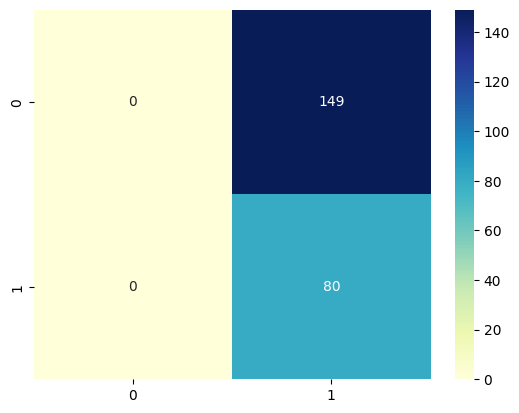

In [781]:
cm = confusion_matrix(y_m1_test, y_m1_pred)
sns.heatmap(cm, cmap="YlGnBu", annot=True, fmt='d');

In [771]:
# Print classification report for more information
print(classification_report(y_m1_test, y_m1_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       149
           1       0.35      1.00      0.52        80

    accuracy                           0.35       229
   macro avg       0.17      0.50      0.26       229
weighted avg       0.12      0.35      0.18       229



# SGDClassifier

In [772]:
sgd_classifier_m1 = SGDClassifier(random_state=RSEED)
scores = cross_val_score(sgd_classifier_m1, X_m1_train, y_m1_train, cv=5, n_jobs=-1)

# Evaluation 
print('Score (scaled):', round(scores.mean(), 4))

Score (scaled): 0.6598


In [773]:
sgd_classifier_m1 = SGDClassifier(random_state=RSEED)
scores = cross_val_score(sgd_classifier_m1, X_m1_train, y_m1_train, cv=5, n_jobs=-1)

# Evaluation 
print('Score (scaled):', round(scores.mean(), 4))

Score (scaled): 0.6598


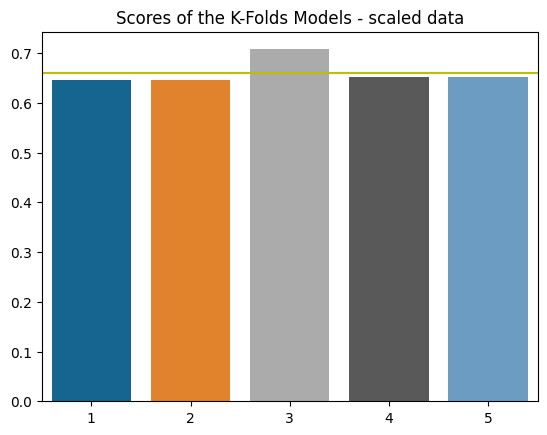

In [774]:
plt.axhline(y=scores.mean(), color='y', linestyle='-')
sns.barplot(x=[1,2,3,4, 5],y=scores).set_title('Scores of the K-Folds Models - scaled data');

In [775]:
param_grid = {"loss" : ["hinge", "log", "squared_hinge", "modified_huber"],
              "alpha" : np.linspace(0.0001, 0.5, 500),
              "penalty" : ["l2", "l1", "none"]
             }

# Instantiate random search and define the metric to optimize 
rs = RandomizedSearchCV(SGDClassifier(random_state=RSEED), param_grid, scoring='accuracy',
                  cv=5, verbose=5, n_jobs=-1, n_iter=10, random_state=RSEED)

# Fit randomized search object to data
start = timer()
rs.fit(X_m1_train, y_m1_train)
end = timer()
rgs_time = end-start

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END alpha=0.10729298597194388, loss=log, penalty=none;, score=nan total time=   0.0s
[CV 2/5] END alpha=0.10729298597194388, loss=log, penalty=none;, score=nan total time=   0.0s
[CV 4/5] END alpha=0.10729298597194388, loss=log, penalty=none;, score=nan total time=   0.0s
[CV 3/5] END alpha=0.10729298597194388, loss=log, penalty=none;, score=nan total time=   0.0s
[CV 5/5] END alpha=0.10729298597194388, loss=log, penalty=none;, score=nan total time=   0.0s
[CV 1/5] END alpha=0.38579438877755506, loss=log, penalty=l2;, score=0.645 total time=   0.0s
[CV 2/5] END alpha=0.38579438877755506, loss=log, penalty=l2;, score=0.645 total time=   0.0s
[CV 3/5] END alpha=0.38579438877755506, loss=log, penalty=l2;, score=0.651 total time=   0.0s
[CV 1/5] END alpha=0.11230200400801603, loss=hinge, penalty=l2;, score=0.645 total time=   0.0s
[CV 5/5] END alpha=0.38579438877755506, loss=log, penalty=l2;, score=0.604 total time=   0.

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/26June_piplines_Diabetes_Challenge/ds-diabetes-challenge/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/26June_piplines_Diabetes_Challenge/ds-diabetes-challenge/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/26June_piplines_Diabetes_Challenge/ds-diabetes-challenge/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which 

[CV 5/5] END alpha=0.11230200400801603, loss=hinge, penalty=l2;, score=0.651 total time=   0.0s
[CV 3/5] END alpha=0.09827675350701402, loss=log, penalty=l1;, score=0.651 total time=   0.0s
[CV 4/5] END alpha=0.09827675350701402, loss=log, penalty=l1;, score=0.651 total time=   0.0s


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/26June_piplines_Diabetes_Challenge/ds-diabetes-challenge/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/26June_piplines_Diabetes_Challenge/ds-diabetes-challenge/.venv/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:163: FutureWarning: The loss 'log' was deprecated in v1.1 and will be removed in version 1.3. Use `loss='log_loss'` which is equivalent.
  warnings.warn(


In [776]:
# Best score
print('Best score:', round(rs.best_score_, 3))

# Best parameters
print('Best parameters:', rs.best_params_)

Best score: 0.679
Best parameters: {'penalty': 'l2', 'loss': 'modified_huber', 'alpha': 0.2866158316633266}


# Training KNN Classifier

0.012544291996164247


<Axes: >

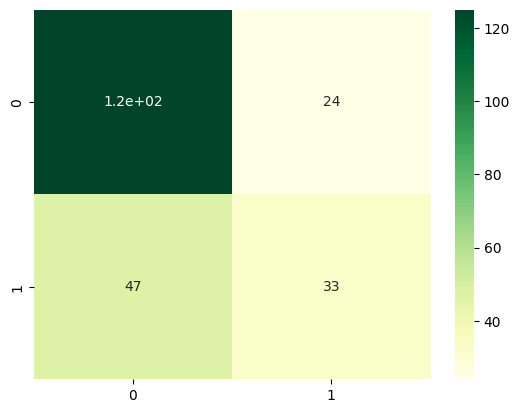

In [777]:
start = timer()
# Train model
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_m1_train, np.ravel(y_m1_train))
# Predict on test set
y_m1_pred_knn = knn.predict(X_m1_test)
end = timer()
rgs_time = end - start
print(rgs_time)
# Print confusion matrix
sns.heatmap(confusion_matrix(y_m1_test, y_m1_pred_knn), annot = True, cmap = 'YlGn')

In [778]:
# Print classification report for more information
print(classification_report(y_m1_test, y_m1_pred_knn))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78       149
           1       0.58      0.41      0.48        80

    accuracy                           0.69       229
   macro avg       0.65      0.63      0.63       229
weighted avg       0.68      0.69      0.68       229



In [779]:
# Defining parameter grid (as dictionary)
#n_neighbors=10, metric='minkowski', p=2, weights = 'distance'
param_grid = {"n_neighbors" : [5, 10, 15, 20, 25], #this actually defines the model you use
              "p" : [1, 2, 3, 4, 5],
              "weights" : ["uniform", "distance"]
             }

# Instantiate gridsearch and define the metric to optimize 
gs = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='accuracy',
                  cv=5, verbose=5, n_jobs=-1)

# Fit gridsearch object to data.. also lets see how long it takes
start = timer()
gs.fit(X_m1_train, y_m1_train)
end = timer()
gs_time = end-start

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 3/5] END n_neighbors=5, p=1, weights=distance;, score=0.717 total time=   0.0s
[CV 4/5] END n_neighbors=5, p=1, weights=distance;, score=0.698 total time=   0.0s
[CV 2/5] END n_neighbors=5, p=1, weights=distance;, score=0.654 total time=   0.0s
[CV 5/5] END n_neighbors=5, p=1, weights=uniform;, score=0.689 total time=   0.0s
[CV 1/5] END n_neighbors=5, p=1, weights=distance;, score=0.626 total time=   0.0s
[CV 2/5] END n_neighbors=5, p=1, weights=uniform;, score=0.673 total time=   0.0s
[CV 3/5] END n_neighbors=5, p=1, weights=uniform;, score=0.726 total time=   0.0s
[CV 2/5] END n_neighbors=5, p=2, weights=uniform;, score=0.673 total time=   0.0s
[CV 1/5] END n_neighbors=5, p=1, weights=uniform;, score=0.617 total time=   0.0s
[CV 5/5] END n_neighbors=5, p=2, weights=uniform;, score=0.689 total time=   0.0s
[CV 4/5] END n_neighbors=5, p=2, weights=uniform;, score=0.717 total time=   0.0s
[CV 4/5] END n_neighbors=5, p=1,

In [780]:
# Best score
print('Best score:', round(gs.best_score_, 3))

# Best parameters
print('Best parameters:', gs.best_params_)

Best score: 0.727
Best parameters: {'n_neighbors': 20, 'p': 1, 'weights': 'uniform'}


In [704]:
df_dbdc_dp.shape

(761, 9)

In [706]:
y.shape

(761,)

In [707]:
X.shape

(761, 6)

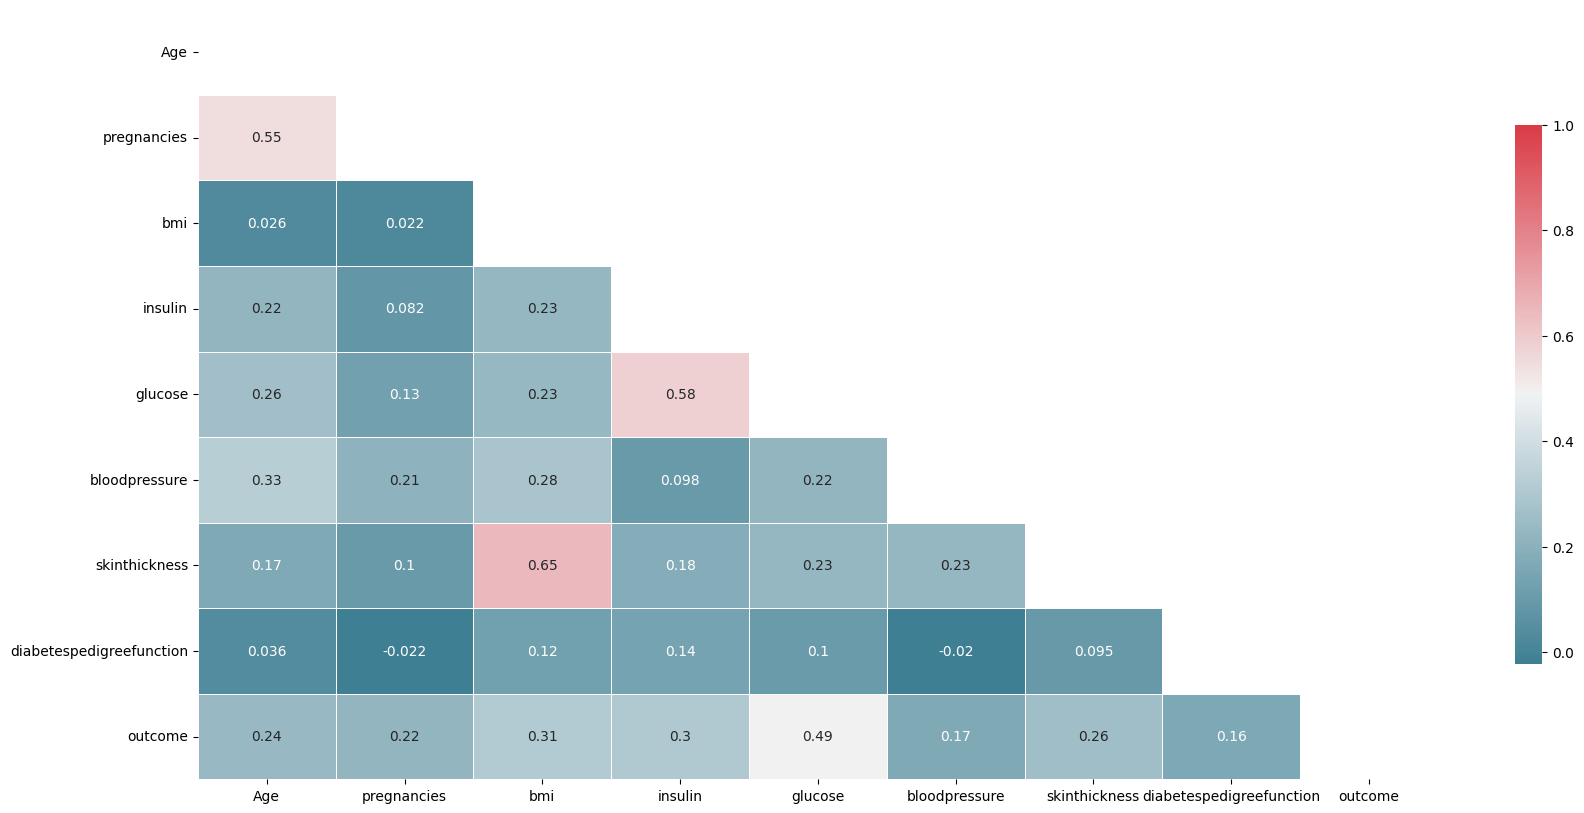

In [497]:
# Compute correlations
plt.figure(figsize = (20,10))
correlations = df_dbdc_dp.corr(numeric_only = True)
# Generate a mask for the upper triangle
mask = np.zeros_like(correlations)
mask[np.triu_indices_from(mask)] = True
# Generate a custom diverging colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlations, mask=mask, cmap=cmap, vmax=1, annot=True,
            linewidths=.5, cbar_kws={"shrink": .7});

In [ ]:
# we drop the id column (NOT THE PATIENT_ID!...we are gonna need it)
df = df.drop(['id'],axis=1)
df.head()

In [ ]:
# Load the data from the database. The schema is called `diabetes`. To connect to the database you need to copy the `.env` file from the visualization or hands-on-ml repository into this repo. Explore the database, try to establish what the relationships between the tables are (1-1, 1-N, N-M). Explain to yourself and the group what data do you see and whether it makes sense. What JOINs are appropriate to use and why? 
# already done

In [ ]:
# Use at least two different classification algorithms we have learned so far to predict Diabetes patients. 
# Logistic Regression, K-nearest Neighbors, Decision Tree



# Logistic Regression

 # K-nearest Neighbors

# Decision Tree

In [ ]:
# Discuss before you start with the modeling process which **evaluation metric** you choose and explain why.


In [ ]:
# Implement a GridSearchCV or RandomizedSearchCV to tune the hyperparameters of your model.


In [ ]:
# **Optional:** If you have time at the end, try to use sklearn's pipline module to encapsulate all the steps into a pipeline.


In [ ]:
## Don't forget to split your data in train and test set. And analyze your final model on the test data. It might also be necessary to scale your data in order to improve the performance of some of the models.